---
---
---
# **프로젝트: 모델 바꿔보기**


**실험 목표**

*   Hourglass 모델과 simplebaseline 모델을 정성적 및 정량적 비교 분석으로 두 모델의 차이점과 개선안을 학습



**실험 설정**

*   데이터셋 : MPII(압축 해제 → TFRecord 생성 기반)
*   입력사이즈 :  256×256
*   Heatmap: 64×64
*   Sigma : 2.0
*   Optimizer/LR : Adam 2e-4
*   Batch size: 16
*   Epoch: 5 (두 모델 동일)


**모델 구성**

*   StackedHourglass: stacks=2, depth=4, filters=256
*   SimpleBaseline: ResNet50(conv4_out) + Deconv×2 + heatmap head



## 0. 환경 준비

In [ ]:
!nvidia-smi -L || true

import os, glob, shutil, json, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

!apt-get -qq update
!apt-get -qq install -y unzip
!pip -q install gdown

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)


GPU 0: Tesla T4 (UUID: GPU-7fd31141-78bc-2c2d-3db9-0d597fae34e6)
TensorFlow: 2.19.0
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Mixed precision: <DTypePolicy "mixed_float16">


## 1. 작업 디렉토리 생성

In [ ]:
ROOT = "/content/mpii"
DATA_DIR = os.path.join(ROOT, "data")
DATA_MODELS_DIR = os.path.join(DATA_DIR, "models")
IMAGES_DIR = os.path.join(ROOT, "images")
ANNO_DIR = os.path.join(ROOT, "mpii_human_pose_v1_u12_2")
MODELS_DIR = os.path.join(ROOT, "models")
TFREC_DIR = os.path.join(ROOT, "tfrecords")

for d in [ROOT, DATA_DIR, DATA_MODELS_DIR, IMAGES_DIR, ANNO_DIR, MODELS_DIR, TFREC_DIR]:
    os.makedirs(d, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("IMAGES_DIR:", IMAGES_DIR)
print("ANNO_DIR:", ANNO_DIR)


ROOT: /content/mpii
DATA_DIR: /content/mpii/data
IMAGES_DIR: /content/mpii/images
ANNO_DIR: /content/mpii/mpii_human_pose_v1_u12_2


## 2. 업로드된 알집파일을 /data에 복사

In [ ]:
def find_file(patterns, roots=("/content",)):
    import glob, os
    for r in roots:
        for pat in patterns:
            hits = glob.glob(os.path.join(r, "**", pat), recursive=True)
            hits = [h for h in hits if "/proc/" not in h and "/sys/" not in h and "/dev/" not in h]
            if hits:
                return sorted(hits, key=len)[0]
    return None

src_mpii_zip = find_file(["mpii.zip"])
src_u12_zip  = find_file(["mpii_human_pose_v1_u12_2.zip", "*u12_2*.zip"])

print("Found zip:")
print(" - mpii.zip:", src_mpii_zip)
print(" - u12_2.zip:", src_u12_zip)

assert src_mpii_zip is not None, "mpii.zip을 코랩에 업로드하세요."
assert src_u12_zip  is not None, "mpii_human_pose_v1_u12_2.zip을 코랩에 업로드하세요."

mpii_zip = os.path.join(DATA_DIR, "mpii.zip")
u12_zip  = os.path.join(DATA_DIR, "mpii_human_pose_v1_u12_2.zip")

import shutil, os
if not os.path.exists(mpii_zip):
    shutil.copy(src_mpii_zip, mpii_zip)
if not os.path.exists(u12_zip):
    shutil.copy(src_u12_zip, u12_zip)

print("DATA_DIR files:", sorted(os.listdir(DATA_DIR))[:20])


Found zip:
 - mpii.zip: /content/mpii.zip
 - u12_2.zip: /content/mpii_human_pose_v1_u12_2.zip
DATA_DIR files: ['models', 'mpii.zip', 'mpii_human_pose_v1_u12_2.zip']


## 3. Google Drive 링크에서 `mpii_human_pose_v1.tar.gz` 가져오기

In [ ]:
import gdown, os, glob, shutil

FILE_ID = "1J7kb5pQZO4ozyZUKfLgXf-HqU_PrqZpS"
tar_gz = os.path.join(DATA_DIR, "mpii_human_pose_v1.tar.gz")

if not os.path.exists(tar_gz):
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    print("Downloading via gdown:", url)
    try:
        gdown.download(url, tar_gz, quiet=False)
    except Exception as e:
        print("gdown failed:", e)

print("tar.gz exists after gdown?", os.path.exists(tar_gz), tar_gz)

if not os.path.exists(tar_gz):
    print("\n[Fallback] Drive mount로 복사합니다.")
    from google.colab import drive
    drive.mount("/content/drive")
    cands = glob.glob("/content/drive/MyDrive/**/mpii_human_pose_v1.tar.gz", recursive=True)
    print("found in Drive:", cands[:3])
    assert cands, "Drive에서 mpii_human_pose_v1.tar.gz를 찾지 못했습니다. MyDrive에 업로드되어 있는지 확인하세요."
    shutil.copy(cands[0], tar_gz)

print("FINAL tar.gz exists?", os.path.exists(tar_gz), tar_gz)
assert os.path.exists(tar_gz), "mpii_human_pose_v1.tar.gz 확보 실패 (공유권한/Drive 경로 확인)"


gdown failed: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1J7kb5pQZO4ozyZUKfLgXf-HqU_PrqZpS

but Gdown can't. Please check connections and permissions.
tar.gz exists after gdown? False /content/mpii/data/mpii_human_pose_v1.tar.gz

[Fallback] Drive mount로 복사합니다.
Mounted at /content/drive
found in Drive: ['/content/drive/MyDrive/mpii_human_pose_v1.tar.gz']
FINAL tar.gz exists? True /content/mpii/data/mpii_human_pose_v1.tar.gz


## 4. 압축 해제 및 디렉토리 배치

In [ ]:
import glob, os, shutil

!unzip -q -o "{os.path.join(DATA_DIR,'mpii.zip')}" -d "{ROOT}"
!unzip -q -o "{os.path.join(DATA_DIR,'mpii_human_pose_v1_u12_2.zip')}" -d "{ROOT}"

tar_gz = os.path.join(DATA_DIR, "mpii_human_pose_v1.tar.gz")
!tar -xzf "{tar_gz}" -C "{DATA_DIR}" || true

jpgs = glob.glob(os.path.join(DATA_DIR, "**", "*.jpg"), recursive=True) + glob.glob(os.path.join(DATA_DIR, "**", "*.jpeg"), recursive=True)
copied = 0
for p in jpgs:
    dst = os.path.join(IMAGES_DIR, os.path.basename(p))
    if not os.path.exists(dst):
        try:
            shutil.copy(p, dst)
            copied += 1
        except Exception:
            pass

print("Copied jpg into images/:", copied)
print("Total images/*.jpg:", len(glob.glob(os.path.join(IMAGES_DIR, '*.jpg'))))

TRAIN_JSON = os.path.join(ANNO_DIR, "train.json")
VAL_JSON   = os.path.join(ANNO_DIR, "validation.json")
print("TRAIN_JSON exists?", os.path.exists(TRAIN_JSON), TRAIN_JSON)
print("VAL_JSON exists?  ", os.path.exists(VAL_JSON),   VAL_JSON)

if not os.path.exists(TRAIN_JSON) or not os.path.exists(VAL_JSON):
    print("train/validation json not found -> fallback download (if available)")
    os.makedirs(ANNO_DIR, exist_ok=True)
    if not os.path.exists(TRAIN_JSON):
        !wget -nc -O "{TRAIN_JSON}" https://d3s0tskafalll9.cloudfront.net/media/documents/train.json || true
    if not os.path.exists(VAL_JSON):
        !wget -nc -O "{VAL_JSON}" https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json || true

assert len(glob.glob(os.path.join(IMAGES_DIR, '*.jpg'))) > 0, "images/*.jpg가 없습니다. tar.gz 내용/복사 단계 확인 필요"
assert os.path.exists(TRAIN_JSON) and os.path.exists(VAL_JSON), "train.json/validation.json이 필요합니다."


[/content/mpii/data/mpii_human_pose_v1_u12_2.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/mpii/data/mpii_human_pose_v1_u12_2.zip or
        /content/mpii/data/mpii_human_pose_v1_u12_2.zip.zip, and cannot find /content/mpii/data/mpii_human_pose_v1_u12_2.zip.ZIP, period.
Copied jpg into images/: 24984
Total images/*.jpg: 24984
TRAIN_JSON exists? False /content/mpii/mpii_human_pose_v1_u12_2/train.json
VAL_JSON exists?   False /content/mpii/mpii_human_pose_v1_u12_2/validation.json
train/validation json not found -> fallback download (if available)
--2026-03-04 21:29:31--  https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.95

## 5. TFRecord 생성

In [ ]:
import tensorflow as tf
import numpy as np
import os, json

TRAIN_TFRECORD = os.path.join(TFREC_DIR, "train.tfrecord")
VAL_TFRECORD   = os.path.join(TFREC_DIR, "val.tfrecord")
NUM_JOINTS = 16

def _bytes_feature(v: bytes):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[v]))

def _float_feature_list(arr):
    arr = np.asarray(arr, dtype=np.float32).reshape(-1)
    return tf.train.Feature(float_list=tf.train.FloatList(value=arr.tolist()))

def _load_annos(json_path):
    with open(json_path, "r") as f:
        annos = json.load(f)
    if isinstance(annos, dict) and "annotations" in annos:
        annos = annos["annotations"]
    return annos

def _extract_image_name(a: dict):
    if isinstance(a.get("image"), str):
        return a["image"]
    if isinstance(a.get("image"), dict) and "name" in a["image"]:
        return a["image"]["name"]
    for k in ["filename", "file_name", "name", "img", "img_path", "image_path"]:
        if k in a and isinstance(a[k], str):
            return a[k]
    raise KeyError("이미지 파일명 키를 찾지 못했습니다.")

def _extract_keypoints(a: dict, num_joints=16):
    if "joints" in a and "joints_vis" in a:
        joints = np.array(a["joints"], dtype=np.float32).reshape(-1, 2)
        vis = np.array(a["joints_vis"], dtype=np.float32).reshape(-1)
        vis = vis[:joints.shape[0]]
        v = np.where(vis > 0, 2.0, 0.0).astype(np.float32)
        kp = np.concatenate([joints, v[:,None]], axis=1)
    elif "keypoints" in a:
        kp = np.array(a["keypoints"], dtype=np.float32).reshape(-1, 3)
    elif all(k in a for k in ["x","y"]):
        x = np.array(a["x"], dtype=np.float32)
        y = np.array(a["y"], dtype=np.float32)
        v = np.array(a.get("vis", np.ones_like(x)*2.0), dtype=np.float32)
        if v.ndim == 1:
            v = np.where(v > 0, 2.0, 0.0)
        kp = np.stack([x,y,v], axis=-1)
    else:
        raise KeyError("keypoints/joints 구조를 찾지 못했습니다.")

    kp = kp.reshape(-1, 3)
    kp = kp[:num_joints, :]
    if kp.shape[0] != num_joints:
        pad = np.zeros((num_joints-kp.shape[0],3), np.float32)
        kp = np.concatenate([kp,pad], axis=0)

    neg = (kp[:,0] < 0) | (kp[:,1] < 0)
    kp[neg,2] = 0.0
    return kp

def write_tfrecord(json_path, out_path):
    annos = _load_annos(json_path)
    n_ok, n_skip_img, n_skip_parse = 0, 0, 0
    with tf.io.TFRecordWriter(out_path) as w:
        for a in annos:
            try:
                img_name = _extract_image_name(a)
                img_path = img_name if os.path.isabs(img_name) else os.path.join(IMAGES_DIR, img_name)
                if not tf.io.gfile.exists(img_path):
                    n_skip_img += 1
                    continue
                kp = _extract_keypoints(a, NUM_JOINTS)
                ex = tf.train.Example(features=tf.train.Features(feature={
                    "image_path": _bytes_feature(img_path.encode("utf-8")),
                    "keypoints": _float_feature_list(kp),
                }))
                w.write(ex.SerializeToString())
                n_ok += 1
            except Exception:
                n_skip_parse += 1
                continue
    print(f"written: {out_path}")
    print(f"  ok={n_ok}, skip_no_image={n_skip_img}, skip_parse={n_skip_parse}, total={len(annos)}")

REBUILD_TFRECORD = False
if REBUILD_TFRECORD or (not os.path.exists(TRAIN_TFRECORD)):
    write_tfrecord(TRAIN_JSON, TRAIN_TFRECORD)
if REBUILD_TFRECORD or (not os.path.exists(VAL_TFRECORD)):
    write_tfrecord(VAL_JSON, VAL_TFRECORD)

def count_records(path, max_count=5_000_000):
    n=0
    for _ in tf.data.TFRecordDataset(path):
        n += 1
        if n >= max_count:
            break
    return n

ct_train = count_records(TRAIN_TFRECORD)
ct_val = count_records(VAL_TFRECORD)
print("Record counts:", {"train": ct_train, "val": ct_val})

assert ct_train > 0, "train.tfrecord 레코드가 0입니다. (이미지 파일명/경로 불일치 가능)"
assert ct_val > 0, "val.tfrecord 레코드가 0입니다. (이미지 파일명/경로 불일치 가능)"


written: /content/mpii/tfrecords/train.tfrecord
  ok=22246, skip_no_image=0, skip_parse=0, total=22246
written: /content/mpii/tfrecords/val.tfrecord
  ok=2958, skip_no_image=0, skip_parse=0, total=2958
Record counts: {'train': 22246, 'val': 2958}


## 6. 입력 파이프라인 (전처리 + Heatmap 생성)

In [ ]:
IMG_SIZE = 256
OUT_SIZE = 64
SIGMA = 2.0
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
NUM_JOINTS = 16

def parse_tfrecord(example_proto):
    feature_desc = {
        "image_path": tf.io.FixedLenFeature([], tf.string),
        "keypoints": tf.io.VarLenFeature(tf.float32),
    }
    ex = tf.io.parse_single_example(example_proto, feature_desc)
    image_path = ex["image_path"]
    keypoints = tf.sparse.to_dense(ex["keypoints"])
    keypoints = tf.reshape(keypoints, [NUM_JOINTS, 3])
    return image_path, keypoints

def load_and_preprocess(image_path, keypoints, training=True):
    img_bytes = tf.io.read_file(image_path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)

    h = tf.cast(tf.shape(img)[0], tf.float32)
    w = tf.cast(tf.shape(img)[1], tf.float32)

    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")

    x = keypoints[:, 0] * (tf.cast(IMG_SIZE, tf.float32) / w)
    y = keypoints[:, 1] * (tf.cast(IMG_SIZE, tf.float32) / h)
    v = keypoints[:, 2]

    if training:
        do_flip = tf.random.uniform([]) < 0.5
        img = tf.cond(do_flip, lambda: tf.image.flip_left_right(img), lambda: img)
        x = tf.cond(do_flip, lambda: (tf.cast(IMG_SIZE, tf.float32) - 1.0) - x, lambda: x)

    return img, tf.stack([x, y, v], axis=-1)

def gaussian_2d(H, W, cx, cy, sigma):
    x = tf.range(W, dtype=tf.float32)
    y = tf.range(H, dtype=tf.float32)
    yy, xx = tf.meshgrid(y, x, indexing="ij")
    return tf.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))

def keypoints_to_heatmaps(keypoints):
    scale = tf.cast(OUT_SIZE, tf.float32) / tf.cast(IMG_SIZE, tf.float32)
    xs = keypoints[:, 0] * scale
    ys = keypoints[:, 1] * scale
    vs = keypoints[:, 2]

    def per_joint(i):
        valid = tf.cast(vs[i] > 0.0, tf.float32)
        g = gaussian_2d(OUT_SIZE, OUT_SIZE, xs[i], ys[i], SIGMA)
        return g * valid

    hms = tf.map_fn(per_joint, tf.range(NUM_JOINTS), fn_output_signature=tf.float32)
    return tf.transpose(hms, [1, 2, 0])

def make_dataset(tfrecord_path, training=True):
    ds = tf.data.TFRecordDataset(tfrecord_path, num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda p, k: load_and_preprocess(p, k, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda img, kp: (img, keypoints_to_heatmaps(kp)), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1024, seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.batch(BATCH_SIZE, drop_remainder=training).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(TRAIN_TFRECORD, training=True)
val_ds   = make_dataset(VAL_TFRECORD, training=False)

def count_records(path, max_count=5_000_000):
    n=0
    for _ in tf.data.TFRecordDataset(path):
        n += 1
        if n >= max_count:
            break
    return n

n_train = count_records(TRAIN_TFRECORD)
n_val = count_records(VAL_TFRECORD)
raw_steps = max(1, n_train // BATCH_SIZE)
STEPS_PER_EPOCH = min(raw_steps, 500)
VAL_STEPS = min(max(1, n_val // BATCH_SIZE), 200)

print("n_train:", n_train, "n_val:", n_val)
print("STEPS_PER_EPOCH:", STEPS_PER_EPOCH, "VAL_STEPS:", VAL_STEPS)

xb, yb = next(iter(train_ds.take(1)))
print("img batch:", xb.shape, xb.dtype)
print("hm  batch:", yb.shape, yb.dtype)


n_train: 22246 n_val: 2958
STEPS_PER_EPOCH: 500 VAL_STEPS: 184
img batch: (16, 256, 256, 3) <dtype: 'float32'>
hm  batch: (16, 64, 64, 16) <dtype: 'float32'>


## 7. 모델 구현 (STEP 1: SimpleBaseline 완성)

In [ ]:
from tensorflow.keras import layers, models

def conv_bn_relu(x, filters, k=3, s=1, name=None):
    x = layers.Conv2D(filters, k, strides=s, padding="same", use_bias=False,
                      name=None if name is None else name+"_conv")(x)
    x = layers.BatchNormalization(name=None if name is None else name+"_bn")(x)
    x = layers.ReLU(name=None if name is None else name+"_relu")(x)
    return x

def residual_block(x, filters, name=None):
    shortcut = x
    x = conv_bn_relu(x, filters, 3, 1, name=None if name is None else name+"_1")
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      name=None if name is None else name+"_2_conv")(x)
    x = layers.BatchNormalization(name=None if name is None else name+"_2_bn")(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False,
                                 name=None if name is None else name+"_skip_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=None if name is None else name+"_skip_bn")(shortcut)
    x = layers.Add(name=None if name is None else name+"_add")([x, shortcut])
    x = layers.ReLU(name=None if name is None else name+"_out")(x)
    return x

def build_simplebaseline(num_joints=NUM_JOINTS, img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3), name="image")
    base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    feat = base.get_layer("conv4_block6_out").output  # 16x16 for 256 input

    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False, name="deconv1")(feat)
    x = layers.BatchNormalization(name="deconv1_bn")(x)
    x = layers.ReLU(name="deconv1_relu")(x)

    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False, name="deconv2")(x)
    x = layers.BatchNormalization(name="deconv2_bn")(x)
    x = layers.ReLU(name="deconv2_relu")(x)

    out = layers.Conv2D(num_joints, 1, padding="same", dtype="float32", name="heatmaps")(x)
    return models.Model(inputs, out, name="SimpleBaseline")

def hourglass_module(x, depth, filters, name):
    up1 = residual_block(x, filters, name=f"{name}_up1_d{depth}")
    low1 = layers.MaxPool2D(2,2,padding="same", name=f"{name}_pool_d{depth}")(x)
    low1 = residual_block(low1, filters, name=f"{name}_low1_d{depth}")
    if depth > 1:
        low2 = hourglass_module(low1, depth-1, filters, name=name)
    else:
        low2 = residual_block(low1, filters, name=f"{name}_base")
    low3 = residual_block(low2, filters, name=f"{name}_low3_d{depth}")
    up2  = layers.UpSampling2D(2, interpolation="nearest", name=f"{name}_up_d{depth}")(low3)
    return layers.Add(name=f"{name}_add_d{depth}")([up1, up2])

def build_stacked_hourglass(num_joints=NUM_JOINTS, img_size=IMG_SIZE, stacks=2, depth=4, filters=256):
    inputs = layers.Input(shape=(img_size, img_size, 3), name="image")
    x = conv_bn_relu(inputs, 64, 7, 2, name="stem")
    x = residual_block(x, 128, name="res1")
    x = layers.MaxPool2D(2,2,padding="same", name="pool")(x)
    x = residual_block(x, 128, name="res2")
    x = residual_block(x, filters, name="res3")

    inter = x
    out = None
    for s in range(stacks):
        hg = hourglass_module(inter, depth, filters, name=f"hg{s+1}")
        hg = residual_block(hg, filters, name=f"hg{s+1}_res")
        hg = conv_bn_relu(hg, filters, 1, 1, name=f"hg{s+1}_lin")
        out = layers.Conv2D(num_joints, 1, padding="same", dtype="float32", name=f"heatmaps_s{s+1}")(hg)
        if s < stacks-1:
            inter = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"merge{s+1}_conv")(hg)
            inter = layers.BatchNormalization(name=f"merge{s+1}_bn")(inter)
            inter = layers.Add(name=f"merge{s+1}_add")([inter, x])
    return models.Model(inputs, out, name="StackedHourglass")

sb_model = build_simplebaseline()
hg_model = build_stacked_hourglass()
print("SimpleBaseline output:", sb_model.output_shape)
print("Hourglass output:", hg_model.output_shape)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
SimpleBaseline output: (None, 64, 64, 16)
Hourglass output: (None, 64, 64, 16)


## 8. 학습 (STEP 2) + 비교 (STEP 3)

In [ ]:
def heatmap_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def compile_model(model, lr=2e-4):
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss=heatmap_mse)
    return model

def make_callbacks(name):
    log_dir = os.path.join(ROOT, "runs", name, time.strftime("%Y%m%d-%H%M%S"))
    os.makedirs(log_dir, exist_ok=True)
    cbs = [
        tf.keras.callbacks.TensorBoard(log_dir=log_dir),
        tf.keras.callbacks.ModelCheckpoint(os.path.join(log_dir, "best.keras"), monitor="val_loss", save_best_only=True),
    ]
    return cbs, log_dir

EPOCHS = 5

hg = compile_model(build_stacked_hourglass(stacks=2, depth=4, filters=256), lr=2e-4)
hg_cbs, hg_log = make_callbacks("hourglass")
hist_hg = hg.fit(train_ds, validation_data=val_ds,
                 epochs=EPOCHS, steps_per_epoch=STEPS_PER_EPOCH, validation_steps=VAL_STEPS,
                 callbacks=hg_cbs, verbose=1)

sb = compile_model(build_simplebaseline(), lr=2e-4)
sb_cbs, sb_log = make_callbacks("simplebaseline")
hist_sb = sb.fit(train_ds, validation_data=val_ds,
                 epochs=EPOCHS, steps_per_epoch=STEPS_PER_EPOCH, validation_steps=VAL_STEPS,
                 callbacks=sb_cbs, verbose=1)

print("Hourglass log:", hg_log)
print("SimpleBaseline log:", sb_log)


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 321s 411ms/step - loss: 0.0716 - val_loss: 0.0033
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 361ms/step - loss: 0.0034 - val_loss: 0.0036
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 189s 379ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 207s 415ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 209s 418ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 248s 330ms/step - loss: 0.0384 - val_loss: 0.0030
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 315ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 320ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 402ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 407ms/step - loss: 0.0024 - val_loss: 0.0024
Hourglass log: /content/mpii/runs/hourglass/20260304-213001
SimpleBaseline log: /content/mpii/runs/simplebasel

## 9. Loss 곡선 비교

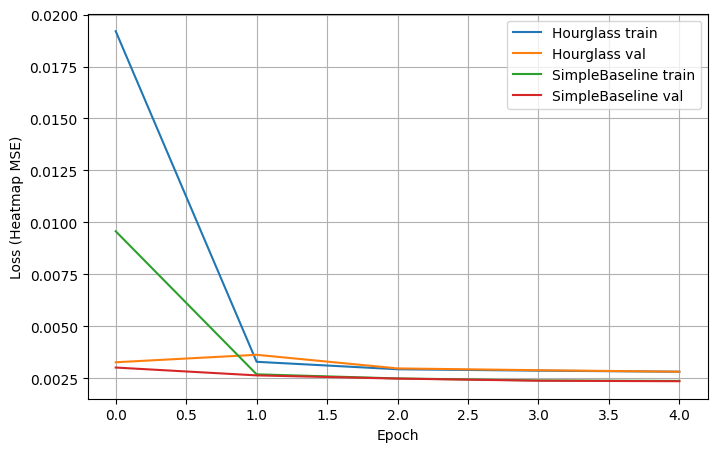

In [ ]:
def plot_histories(h1, label1, h2, label2):
    plt.figure(figsize=(8,5))
    plt.plot(h1.history["loss"], label=f"{label1} train")
    plt.plot(h1.history["val_loss"], label=f"{label1} val")
    plt.plot(h2.history["loss"], label=f"{label2} train")
    plt.plot(h2.history["val_loss"], label=f"{label2} val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (Heatmap MSE)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories(hist_hg, "Hourglass", hist_sb, "SimpleBaseline")


## 10. Pose Estimation 정성적 분석을 위한 시각화 비교

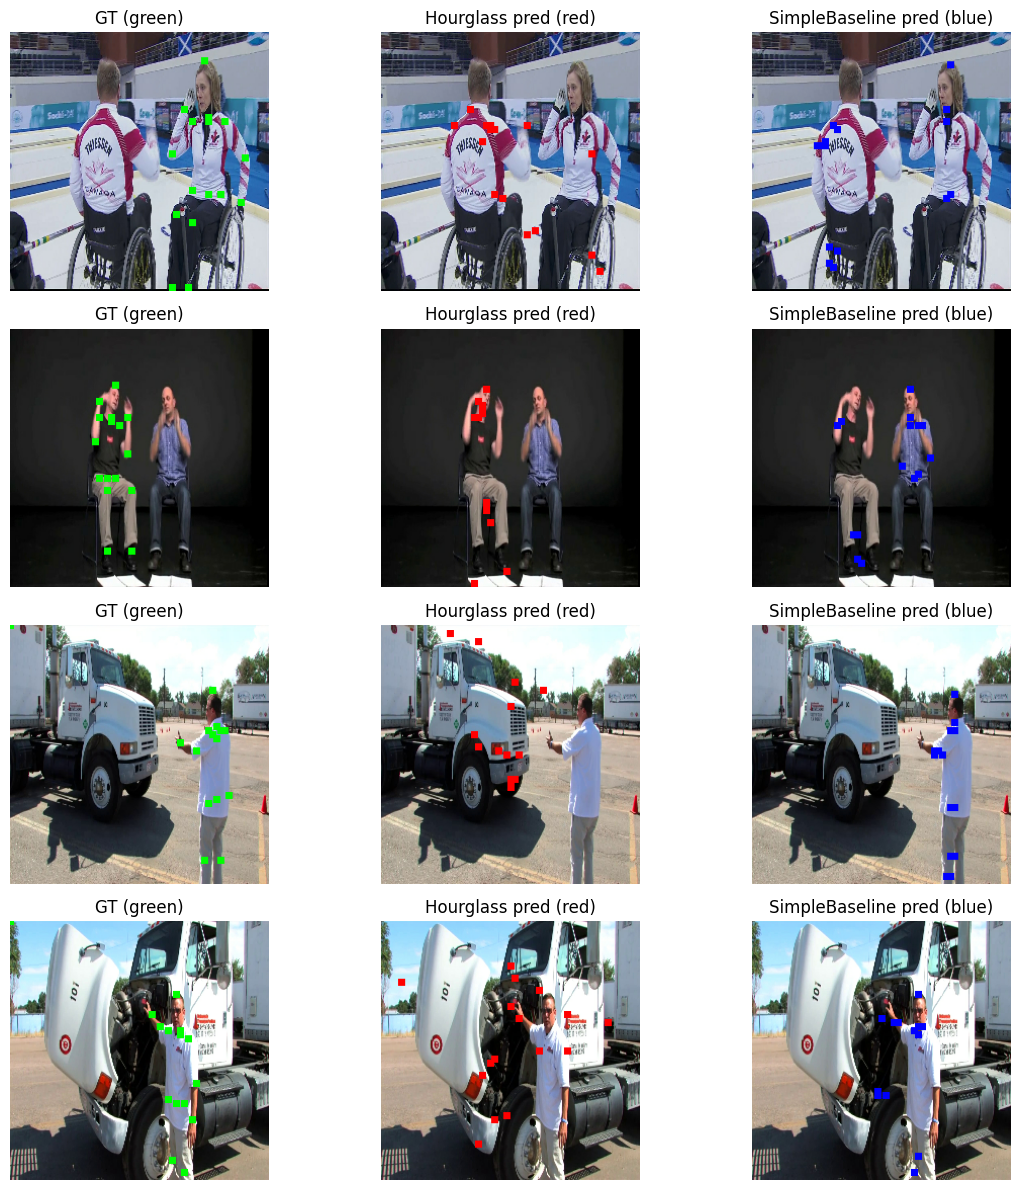

In [ ]:
def heatmaps_to_keypoints(hm):
    H,W,J = hm.shape
    coords=[]
    for j in range(J):
        idx = np.argmax(hm[:,:,j])
        y,x = np.unravel_index(idx, (H,W))
        coords.append([x*(IMG_SIZE/W), y*(IMG_SIZE/H)])
    return np.array(coords, dtype=np.float32)

def draw_keypoints(img, kps, color=(0,1,0), r=3):
    out = img.copy()
    for x,y in kps:
        x=int(np.clip(x,0,IMG_SIZE-1)); y=int(np.clip(y,0,IMG_SIZE-1))
        out[max(0,y-r):min(IMG_SIZE,y+r+1), max(0,x-r):min(IMG_SIZE,x+r+1), :] = color
    return out

imgs, gt_hm = next(iter(val_ds.take(1)))
imgs_np = imgs.numpy()
gt_np = gt_hm.numpy()

pred_hg = hg.predict(imgs, verbose=0)
pred_sb = sb.predict(imgs, verbose=0)

N_SHOW = min(4, imgs_np.shape[0])
plt.figure(figsize=(12, 3*N_SHOW))
for i in range(N_SHOW):
    img = imgs_np[i]
    gt_kp = heatmaps_to_keypoints(gt_np[i])
    hg_kp = heatmaps_to_keypoints(pred_hg[i])
    sb_kp = heatmaps_to_keypoints(pred_sb[i])

    vis_gt = draw_keypoints(img, gt_kp, color=(0,1,0))
    vis_hg = draw_keypoints(img, hg_kp, color=(1,0,0))
    vis_sb = draw_keypoints(img, sb_kp, color=(0,0,1))

    ax1 = plt.subplot(N_SHOW, 3, i*3 + 1); ax1.imshow(vis_gt); ax1.set_title("GT (green)"); ax1.axis("off")
    ax2 = plt.subplot(N_SHOW, 3, i*3 + 2); ax2.imshow(vis_hg); ax2.set_title("Hourglass pred (red)"); ax2.axis("off")
    ax3 = plt.subplot(N_SHOW, 3, i*3 + 3); ax3.imshow(vis_sb); ax3.set_title("SimpleBaseline pred (blue)"); ax3.axis("off")

plt.tight_layout()
plt.show()


**결과 분석**

*   정량적 분석 결과로 SimpleBaseline은 Hourglass보다 더 낮은 validation loss를 기록하였으며, 학습 곡선도 더 빠르고 안정적으로 수렴하였다. 학습을 통하여 SimpleBaseline의 최종 validation loss는 약 0.0024, Hourglass의 최종 validation loss는 약 0.0028로 나타났다. 학습 초반부터 SimpleBaseline의 손실 감소가 빠르게 이루어졌으며, 후반부에도 비교적 안정적으로 수렴하였다. 반면에 Hourglass는 초기에 손실이 크게 감소하였으나, validation loss가 SimpleBaseline보다 다소 높게 유지되었다.
*   정성적 분석 결과(시각화 결과)로 SimpleBaseline은 주요 포인트가 인체 관절 부위에 비교적 잘 집중된 반면, Hourglass는 배경 물체나 주변 구조로 예측이 분산되는 경우가 나타났다. SimpleBaseline은 주요 관절 예측이 사람의 몸통, 어깨, 팔 주변에 잘 정렬되었고 전반적으로 주요 포인트가 인체 영역 내부에 모이는 경향을 보였다. 반면 Hourglass는 일부 샘플에서 주요 포인트가 배경 물체나 주변 구조물 쪽으로 분산되는 현상이 나타났으며, 특히 트럭, 휠체어, 의자와 같이 강한 윤곽을 가진 배경 요소에 오검출되는 모습이 보였다.
*   단, 두 모델 모두 완벽한 예측을 보인 것은 아니다. 하체 관절, 작은 관절 부위, 복잡한 배경이 포함된 경우에는 예측 오차가 여전히 존재하였다.

**실험의 한계점 및 향후 보완점**

*   학습 epoch 수를 5로 설정하여 매우 짧은 추이만 보여주었으나 epoch 수를 더 늘리면 충분한 수렴 여부를 판단할 수 있을 것이다. 현재 결과는 초기 성능 비교 수준으로 해석하는 것이 타당하다.
*   SimpleBaseline은 ImageNet 사전학습이 적용된 ResNet50 백본을 사용한 반면, Hourglass는 사전학습이 활용되지 않았을 것이므로 성능 차이가 구조적인 문제 때문인지, 백본 사전학습 효과 때문인지는 추가 검증이 필요하다.



**회고**

*   이번 실험을 통하여 모델 구조 변경뿐만 아니라 학습 조건, 시각화 방식, 평가 지표까지 포함한 전체 파이프라인 설계의 중요성을 확인하였다.
*   단순한 loss 비교 외에도 정량적 및 정성적 분석을 함께 수행해야 모델의 실제 성능을 더 정확히 이해할 수 있음을 배웠다.

